In [14]:
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [15]:
data = load_breast_cancer()

X = data.data
y = data.target  # 0 = malignant, 1 = benign

# Normalize data (important)
X = X / np.max(X)

print("Dataset shape:", X.shape)

Dataset shape: (569, 30)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [18]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def neural_network(X, weights):
    # Last element is bias
    w = weights[:-1]
    b = weights[-1]
    return sigmoid(np.dot(X, w) + b)

In [19]:
def fitness(weights):
    preds = neural_network(X_train, weights)
    
    # Avoid log(0)
    preds = np.clip(preds, 1e-6, 1 - 1e-6)
    
    # Binary cross-entropy (log loss)
    loss = -np.mean(
        y_train * np.log(preds) + (1 - y_train) * np.log(1 - preds)
    )
    
    return loss

In [20]:
POP_SIZE = 20
GENERATIONS = 30
MUTATION_RATE = 0.4
DIM = X_train.shape[1] + 1  # +1 for bias

In [21]:
def init_population():
    return [np.random.randn(DIM) for _ in range(POP_SIZE)]

In [22]:
def selection(pop, scores):
    indices = np.argsort(scores)
    return [pop[i] for i in indices[:POP_SIZE//2]]

In [23]:
def crossover(p1, p2):
    point = random.randint(1, len(p1)-1)
    return np.concatenate((p1[:point], p2[point:]))

def mutate(child):
    for i in range(len(child)):
        if random.random() < MUTATION_RATE:
            child[i] += np.random.normal(0, 0.5)  # stronger mutation
    return child 

In [24]:
population = init_population()
errors = []

for gen in range(GENERATIONS):
    scores = [fitness(ind) for ind in population]
    
    best_error = min(scores)
    errors.append(best_error)
    
    print(f"Generation {gen+1}, Best Error: {best_error:.4f}")
    
    parents = selection(population, scores)
    new_population = parents.copy()
    
    while len(new_population) < POP_SIZE:
        p1, p2 = random.sample(parents, 2)
        child = crossover(p1, p2)
        child = mutate(child)
        new_population.append(child)
    
    population = new_population

# Best weights
final_scores = [fitness(ind) for ind in population]
best_idx = np.argmin(final_scores)
best_weights = population[best_idx]

print("\nOptimized Weights found")

Generation 1, Best Error: 0.5728
Generation 2, Best Error: 0.5728
Generation 3, Best Error: 0.5575
Generation 4, Best Error: 0.5575
Generation 5, Best Error: 0.5429
Generation 6, Best Error: 0.5163
Generation 7, Best Error: 0.5157
Generation 8, Best Error: 0.5147
Generation 9, Best Error: 0.5100
Generation 10, Best Error: 0.5061
Generation 11, Best Error: 0.4997
Generation 12, Best Error: 0.4827
Generation 13, Best Error: 0.4827
Generation 14, Best Error: 0.4609
Generation 15, Best Error: 0.4604
Generation 16, Best Error: 0.4527
Generation 17, Best Error: 0.4507
Generation 18, Best Error: 0.4407
Generation 19, Best Error: 0.4407
Generation 20, Best Error: 0.4357
Generation 21, Best Error: 0.4357
Generation 22, Best Error: 0.4357
Generation 23, Best Error: 0.4267
Generation 24, Best Error: 0.4205
Generation 25, Best Error: 0.4205
Generation 26, Best Error: 0.4113
Generation 27, Best Error: 0.4113
Generation 28, Best Error: 0.4113
Generation 29, Best Error: 0.4068
Generation 30, Best Err

In [25]:
def predict(X, weights):
    probs = neural_network(X, weights)
    return (probs > 0.5).astype(int)

y_pred = predict(X_test, best_weights)

accuracy = np.mean(y_pred == y_test)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9473684210526315


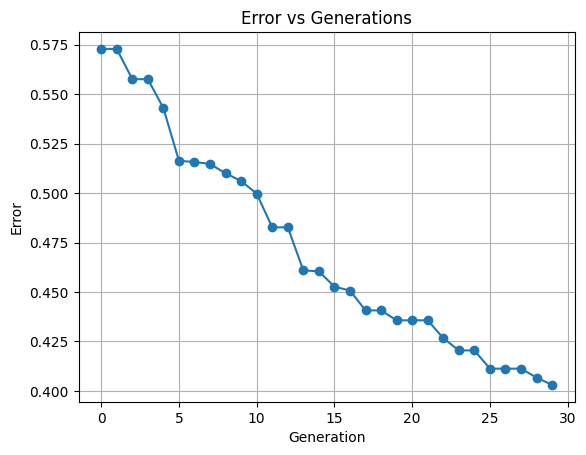

In [26]:
plt.plot(errors, marker='o')
plt.title("Error vs Generations")
plt.xlabel("Generation")
plt.ylabel("Error")
plt.grid()
plt.show()